In [18]:
import time
import pandas as pd
from scipy.sparse import load_npz, hstack, csr_matrix
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
import matplotlib.pyplot as plt

X_train_tfidf = load_npz('datasets/X_train.npz')
X_test_tfidf = load_npz('datasets/X_test.npz')

X_train_extra = pd.read_csv('datasets/X_extra_train.csv').astype(float)
X_test_extra = pd.read_csv('datasets/X_extra_test.csv').astype(float)

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

X_train = hstack([X_train_tfidf, csr_matrix(X_train_extra.values)])
X_test = hstack([X_test_tfidf, csr_matrix(X_test_extra.values)])

classification = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                        max_depth=None, min_samples_split=2,
                                        min_samples_leaf=1, random_state=42)

start_train = time.time()
classification.fit(X_train, y_train)
train_duration = time.time() - start_train

start_pred = time.time()
y_pred = classification.predict(X_test)
predict_duration = time.time() - start_pred

print(f"Training duration: {train_duration:.4f}")
print(f"Predict duration: {predict_duration:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Training duration: 2.1741
Predict duration: 0.0021
Accuracy: 0.9175
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      1977
           1       0.88      0.90      0.89      1209

    accuracy                           0.92      3186
   macro avg       0.91      0.91      0.91      3186
weighted avg       0.92      0.92      0.92      3186



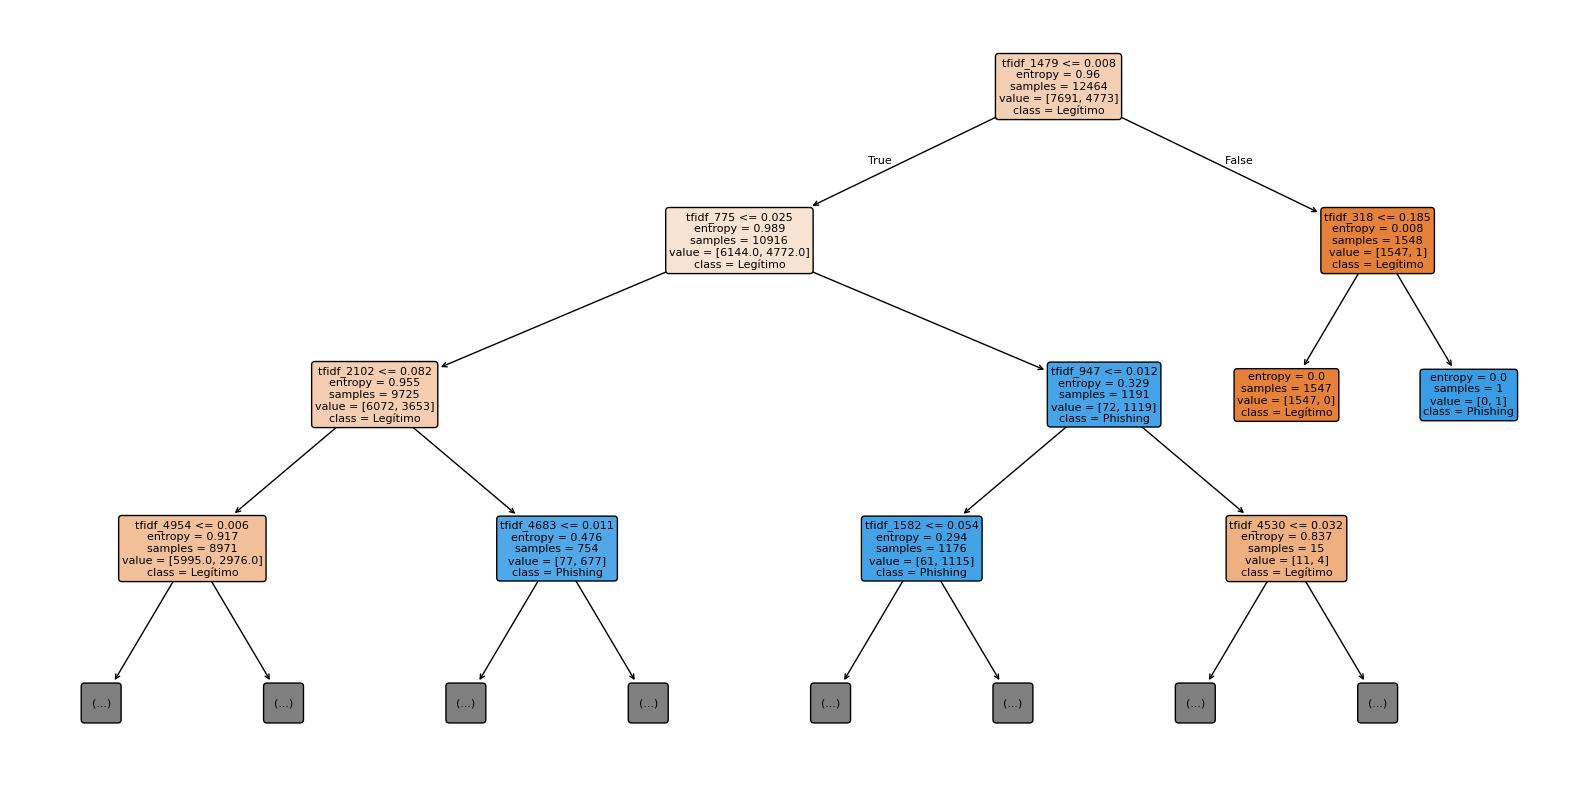

In [19]:
feature_names = [f"tfidf_{i}" for i in range(X_train_tfidf.shape[1])] + X_train_extra.columns.tolist()

plt.figure(figsize=(20, 10))
plot_tree(classification, feature_names=feature_names, class_names=['Legítimo', 'Phishing'],
          filled=True, rounded=True, max_depth=3, fontsize=8)
plt.show()

------------
#### Análisis matriz de confusión

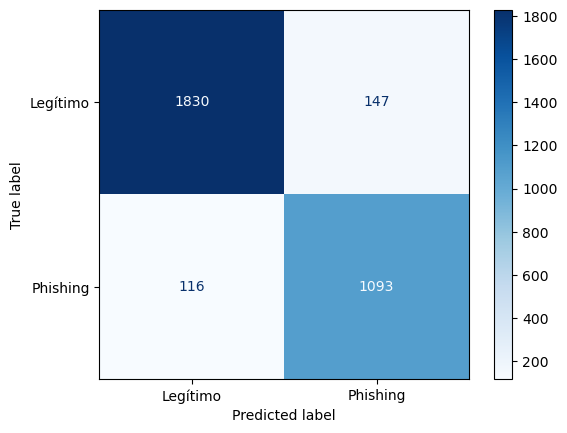

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

----------
#### Curva Roc

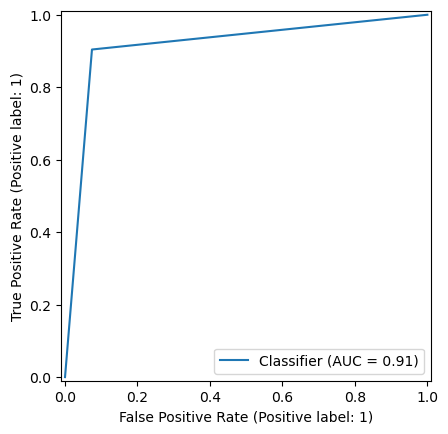

In [21]:
from sklearn.metrics import RocCurveDisplay
y_scores = classification.predict_proba(X_test)[:, 1]
RocCurveDisplay.from_predictions(y_test, y_scores)

-----------
#### Profunidad y features

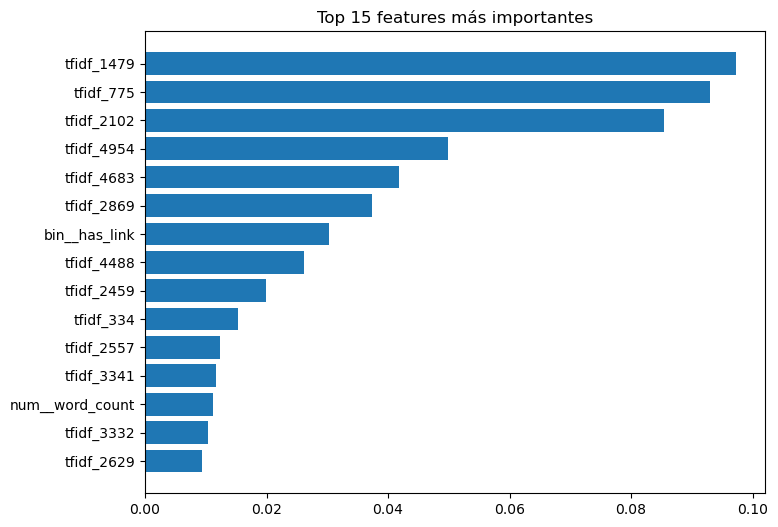

Profundidad del árbol: 116
Cantidad de hojas: 507


In [22]:
import numpy as np
importances = classification.feature_importances_
top_idx = np.argsort(importances)[-15:]
plt.figure(figsize=(8,6))
plt.barh([feature_names[i] for i in top_idx], importances[top_idx])
plt.title('Top 15 features más importantes')
plt.show()

print(f"Profundidad del árbol: {classification.get_depth()}")
print(f"Cantidad de hojas: {classification.get_n_leaves()}")